# The Product Pricer Continued 1, with WanDB Log ...

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for **Fine Tuning**!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [1]:
# imports

import os
import re
# import math
import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
# from items import Item
# import matplotlib.pyplot as plt
import numpy as np
import pickle
# from collections import Counter
from openai import OpenAI
# from anthropic import Anthropic
import wandb

In [2]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
os.environ['WANDB_API_KEY'] = os.getenv('WANDB_API_KEY', 'your-key-if-not-using-env')


In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
openai = OpenAI()

In [6]:
# Wandb Login 

wandb.login()

PROJECT_NAME = "gpt-pricer1"
LOG_TO_WANDB = True

# Configure Weights & Biases to record against our project
os.environ["WANDB_PROJECT"] = PROJECT_NAME
os.environ["WANDB_LOG_MODEL"] = "checkpoint" if LOG_TO_WANDB else "end"
os.environ["WANDB_WATCH"] = "gradients"

os.environ["WANDB_LOG_MODEL"]

wandb: Currently logged in as: samfire5200 (samfire5200-china-systems) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


'checkpoint'

In [7]:
from datetime import datetime

RUN_NAME =  f"{datetime.now():%Y-%m-%d_%H.%M.%S}"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"

if LOG_TO_WANDB:
  wandb.init(project=PROJECT_NAME, name=RUN_NAME)

In [8]:
%matplotlib inline

In [9]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

# Step 1 - Create **Training Dataset** in **jsonl** format and upload to OpenAI

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI
- Fine tune training
- Fine tune validation

In [10]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 500 examples (and 1 epoch)

fine_tune_train = train[:500]
fine_tune_validation = train[500:550]

In [11]:
print(fine_tune_train[0].prompt)
print(fine_tune_validation[0].prompt)

How much does this cost to the nearest dollar?

7 Kids Tablet Google Android 4.4 Quad Core Multi-Touch Screen 8GB Hard Drive Pre-Installed Games and Apps, Google Play Store Pink
Standing screen display size 7 Inches, Screen Resolution Max Screen Resolution 1024 x 600, RAM 8 GB Hard Drive 8 GB, Wireless Type Average Battery Life (in hours) 2 Hours, Brand Wopad, Series Touch, model number Hardware Platform Android, Operating System Android 4.4 KitKat, Weight 1.6 ounces, Dimensions 9 x 7 x 4 inches, Color Pink, Rear Webcam Resolution 3 MP, Processor Brand Rockchip, Processors 4, Computer Memory Type DDR3 SDRAM, Flash Memory Size 8 GB, Power Source Corded Electric, Battery Powered

Price is $67.00
How much does this cost to the nearest dollar?

Ahead Drumsticks 5A
AHEAD sticks are the most advanced drumstick in the world, with a vibration reduction system that reduces hand fatigue and lets you play longer and faster. A replaceable polyurethane cover protects both stick and gear. Ahead Drum

In [12]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [13]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...

def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [14]:
print(make_jsonl(fine_tune_train[:2]), "\n")
print(make_jsonl(fine_tune_validation[:2]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\n7 Kids Tablet Google Android 4.4 Quad Core Multi-Touch Screen 8GB Hard Drive Pre-Installed Games and Apps, Google Play Store Pink\nStanding screen display size 7 Inches, Screen Resolution Max Screen Resolution 1024 x 600, RAM 8 GB Hard Drive 8 GB, Wireless Type Average Battery Life (in hours) 2 Hours, Brand Wopad, Series Touch, model number Hardware Platform Android, Operating System Android 4.4 KitKat, Weight 1.6 ounces, Dimensions 9 x 7 x 4 inches, Color Pink, Rear Webcam Resolution 3 MP, Processor Brand Rockchip, Processors 4, Computer Memory Type DDR3 SDRAM, Flash Memory Size 8 GB, Power Source Corded Electric, Battery Powered"}, {"role": "assistant", "content": "Price is $66.57"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role"

In [15]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [16]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [17]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

## Step 1.1 **Upload** files to OpenAI

In [18]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [19]:
print(train_file.id)
train_file

file-C5BSwojhUXrEiQZqZZKbia


FileObject(id='file-C5BSwojhUXrEiQZqZZKbia', bytes=470025, created_at=1749311234, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [20]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [21]:
print(validation_file.id)
validation_file

file-F2tgTiiSk6JDcW13cjRizP


FileObject(id='file-F2tgTiiSk6JDcW13cjRizP', bytes=47935, created_at=1749311236, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2 - Run training – training loss and validation loss should decrease

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [22]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-iPjrShuvSnhPBF4zNAJ55oie', created_at=1748403931, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm', finished_at=1748404995, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-J7styABA6Qn7ztzkoZTwM9'], seed=42, status='succeeded', trained_tokens=98174, training_file='file-RNUNeZDvKqNrsTkvi9BPZe', validation_file='file-FhS5bTF7N1QJWSFQSc85fB', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer1', entity=None, name=None, tags=None, run_id='ftjob-iPjrShuvSnhPBF4zNAJ55oie'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=Supervised

## Step 2.1 Create or Reused Fine Tune Job in OpenAI 

In [23]:
jobs = openai.fine_tuning.jobs.list(limit=1).data

In [24]:
job_id1 = jobs[0].id
# print(job_id1)
if jobs[0].status not in ["succeeded"]:
    print(f"Job status: '{jobs[0].status}', please wait until the job '{job_id1}' is created....")

## Step 2.2 Create a fine tune job, if Job ID1 == None

In [25]:
wandb_integration = {
    "type": "wandb", 
    "wandb": {"project": PROJECT_NAME}
}

In [26]:
if job_id1 == None:
    openai.fine_tuning.jobs.create(
        training_file=train_file.id,
        validation_file=validation_file.id,
        model="gpt-4o-mini-2024-07-18",
        seed=42,
        hyperparameters={"n_epochs": 1},  # Reduce to minimize overfitting
        integrations=[wandb_integration],
        suffix="pricer-ep1"  # Make suffix meaningful
    )
    
    job_id1 = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [27]:
# job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
job_id = job_id1
job_id

'ftjob-iPjrShuvSnhPBF4zNAJ55oie'

In [28]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-iPjrShuvSnhPBF4zNAJ55oie', created_at=1748403931, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm', finished_at=1748404995, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-J7styABA6Qn7ztzkoZTwM9'], seed=42, status='succeeded', trained_tokens=98174, training_file='file-RNUNeZDvKqNrsTkvi9BPZe', validation_file='file-FhS5bTF7N1QJWSFQSc85fB', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer1', entity=None, name=None, tags=None, run_id='ftjob-iPjrShuvSnhPBF4zNAJ55oie'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learni

In [29]:
openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

'ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm'

In [30]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-KE67A7CrMwV2F5MWUAJsOKC3', created_at=1748405763, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-f2V8ePqaefhIjlneywusAXCt', created_at=1748405758, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-Zo0mejZChHhqezICoo3xCZgz', created_at=1748404998, level='info', message='Evaluating model against our usage policies before enabling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-EAfU2PRMmCmfQj0PqJ88qN5b', created_at=1748404998, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-o2uWQmXUsq0kOJm6WwJD2hoL', created_at=1748404946, level='info', message='Step 500/500: training loss=1.16, validat

# Step 3 - Evaluate results, tweak and repeat

Test our fine tuned model

In [31]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model
print(fine_tuned_model_name)

ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm


In [32]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [33]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nM626 Durun\nAttention! Due to the size of the tires, Packages might be SEPARATED in the courier facility and not be DELIVERED on the SAME DAY, even though we do ship them together. All tracking information can be checked on courier's website.Durun Durun M626 is a performance and high performance, all season tire manufactured for passenger vehicles and SUVs. The tread design and all season compound increase the dry, wet and winter weather traction. The wide grooves actively resist hydroplaning by dispersing water and slush. The constant road contact boosts the steering responsiveness and driving stability greatly. The shoulder tread blocks enhance the cornering ability and power. The M626 has great high speed performing ability as it does not deform under the high speed driving pressure.FeaturesAll"},
 {'role': 'assistan

In [34]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [35]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [36]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [37]:
print(test[0].price)
print(test[0])
print(gpt_fine_tuned(test[0]))

211.99
<295/25R28 M626 Durun = $211.99>
109.65


Process status: 10% | Hits Rate so far: 84.0%
Process status: 20% | Hits Rate so far: 82.0%
Process status: 30% | Hits Rate so far: 81.3%
Process status: 40% | Hits Rate so far: 82.0%
Process status: 50% | Hits Rate so far: 83.2%
Process status: 60% | Hits Rate so far: 84.7%
Process status: 70% | Hits Rate so far: 84.6%
Process status: 80% | Hits Rate so far: 85.5%
Process status: 90% | Hits Rate so far: 85.3%
Process status: 100% | Hits Rate so far: 85.6%


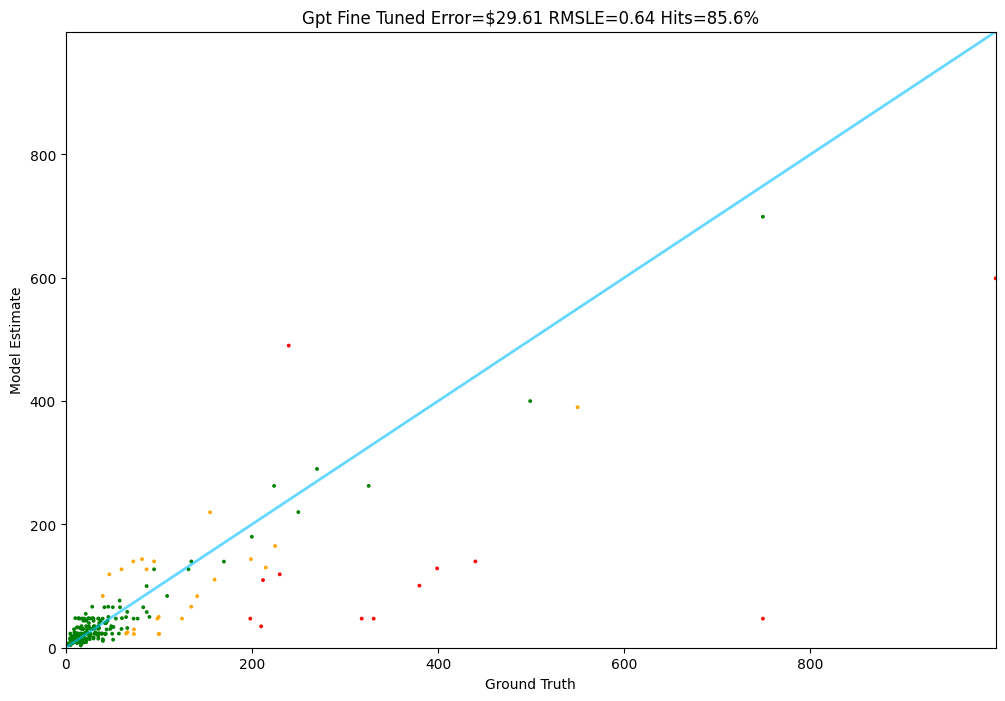

In [38]:
# Run test and log results to wandb if enabled
results = Tester.test(gpt_fine_tuned, test)  # Assumes Tester.test() returns a dict

# Log test results to wandb
if LOG_TO_WANDB and isinstance(results, dict):
    wandb.log({
        "eval/test_accuracy": results.get("accuracy", 0),
        "eval/test_loss": results.get("loss", 0)
    })

In [39]:
# Finish wandb logging
if LOG_TO_WANDB:
    wandb.finish()

### Create a new Fine Tune Job and Check Status

In [40]:
# openai.fine_tuning.jobs.create(
#     training_file=train_file.id,
#     validation_file=validation_file.id,
#     model="gpt-4o-mini-2024-07-18",
#     seed=42,
#     hyperparameters={"n_epochs": 1},  # Reduce to minimize overfitting
#     integrations=[wandb_integration],
#     suffix="pricer-ep1"  # Make suffix meaningful
# )

In [41]:
# jobs = openai.fine_tuning.jobs.list(limit=1).data # Get the first one

In [42]:
# if jobs[0].status not in ["succeeded"]:
#     print(f"\nJob status: {jobs[0].status}, please wait until the job is created....")
# else:
#     print(jobs[0].id, jobs[0].fine_tuned_model)

In [43]:
# openai.fine_tuning.jobs.create(
#     training_file=train_file.id,
#     validation_file=validation_file.id,
#     model="gpt-4o-mini-2024-07-18",
#     seed=42,
#     hyperparameters={"n_epochs": 1},  # Reduce to minimize overfitting
#     integrations=[wandb_integration],
#     suffix="pricer-ep1"  # Make suffix meaningful
# )